0. Data Preperation

In [6]:
from pathlib import Path
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re


input_folder = Path("text")
output_folder = Path("corpus")

output_folder.mkdir(exist_ok=True)

stopwords = set(ENGLISH_STOP_WORDS)
print("Stopwords loaded:", len(stopwords))

def clean_and_remove_stopwords(text: str) -> str:
   
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("ſ", "s")
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[●▪◊]", " ", text)
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    
    return text.strip()

txt_files = list(input_folder.glob("*.txt"))

for file in txt_files:
    text = file.read_text(encoding="utf-8", errors="ignore")
    processed_text = clean_and_remove_stopwords(text)

    (output_folder / file.name).write_text(processed_text, encoding="utf-8")

Stopwords loaded: 318


I will use the concept "price" and choose the window of the sentence the word is in. 

Step 1 — Concept and Data Preparation:

In [7]:
pattern = r'\bprice(?:s|d)?\b'

form_counts = Counter()
total_count = 0

for file in input_folder.glob("*.txt"):
    text = file.read_text(encoding="utf-8", errors="ignore")
    matches = re.findall(pattern, text, flags=re.IGNORECASE)
    total_count += len(matches)
    form_counts.update(m.lower() for m in matches)

print("Total occurrences:", total_count)
print("\nCounts by form:")
for form, count in form_counts.items():
    print(f"{form}: {count}")

doc_counts = {}

for file in input_folder.glob("*.txt"):
    text = file.read_text(encoding="utf-8", errors="ignore")
    matches = re.findall(pattern, text, flags=re.IGNORECASE)
    doc_counts[file.name] = len(matches)

print("Occurrences by document:")
for doc, count in sorted(doc_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{doc}: {count}")



Total occurrences: 2246

Counts by form:
prices: 152
price: 2093
priced: 1
Occurrences by document:
wealth.txt: 1341
A06786.txt: 282
A06788.txt: 133
A06785.txt: 102
A06791.txt: 100
A06789.txt: 90
A07594__Circle_of_Commerce.txt: 45
A32829.txt: 24
A51598.txt: 23
A32827.txt: 20
A32833.txt: 20
B14801__Free_Trade.txt: 19
A07886.txt: 18
A32839.txt: 13
A32828.txt: 7
A69858.txt: 5
A32830.txt: 4
A06790.txt: 0
A32836.txt: 0
A32837.txt: 0
A32838.txt: 0
A50763.txt: 0
A93819.txt: 0


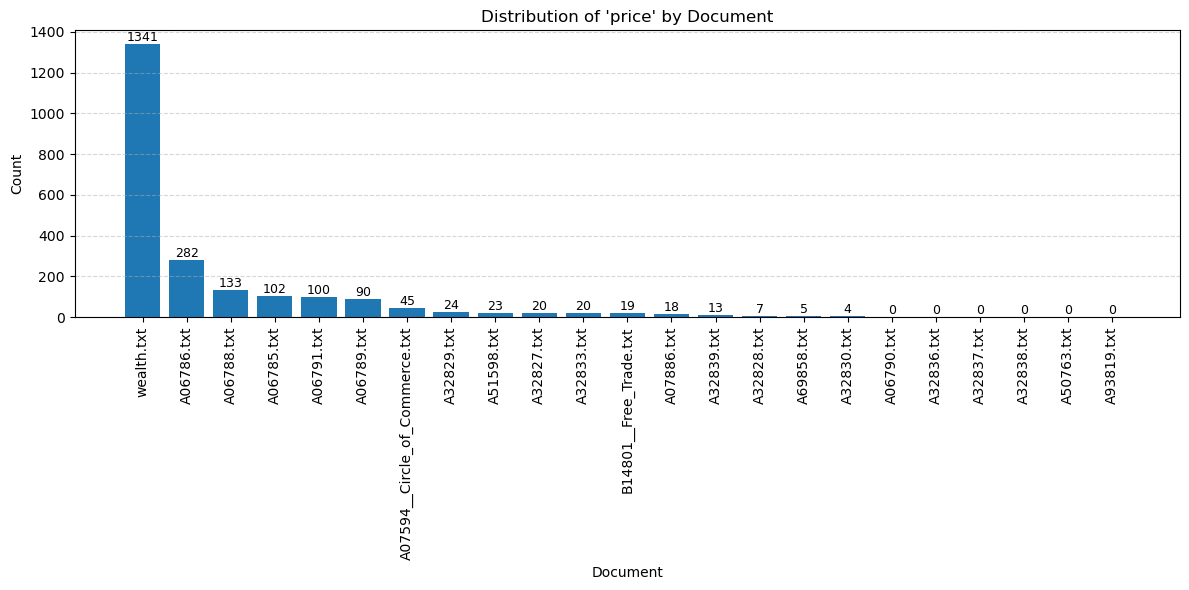

In [8]:
import matplotlib.pyplot as plt

sorted_docs = sorted(doc_counts.items(), key=lambda x: x[1], reverse=True)

doc_names = [x[0] for x in sorted_docs]
counts = [x[1] for x in sorted_docs]

plt.figure(figsize=(12, 6))
bars = plt.bar(doc_names, counts)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Document")
plt.ylabel("Count")
plt.title("Distribution of 'price' by Document")
plt.xticks(rotation=90)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,   # x position
        height,                               # y position
        str(height),                          # label text
        ha="center",
        va="bottom",
        fontsize=9
    )
plt.tight_layout()
plt.savefig("price_distribution_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Step 2 — Named Entity Recognition (spaCy)

In [9]:
from collections import Counter
import spacy
import pandas as pd

nlp = spacy.load("en_core_web_sm")

def split_sentences(text: str):
    sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z])', text)
    return [s.strip() for s in sentences if len(s.strip()) > 10]

rows = []
entity_counts = Counter()

for file in input_folder.glob("*.txt"):
    text = file.read_text(encoding="utf-8", errors="ignore")
    sentences = split_sentences(text)

    for i, sent in enumerate(sentences):
        matches = re.findall(pattern, sent, flags=re.IGNORECASE)

        if matches:
            doc = nlp(sent)

            for match in matches:
                matched_form = match.lower()

                if len(doc.ents) == 0:
                    rows.append({
                        "doc_id": file.name,
                        "sentence_id": i,
                        "matched_form": matched_form,
                        "context": sent,
                        "entity": None,
                        "label": None
                    })

                for ent in doc.ents:
                    rows.append({
                        "doc_id": file.name,
                        "sentence_id": i,
                        "matched_form": matched_form,
                        "context": sent,
                        "entity": ent.text,
                        "label": ent.label_
                    })
                    entity_counts[(ent.text, ent.label_)] += 1
cooccur_df = pd.DataFrame(rows)

entity_freq_df = pd.DataFrame(
    [(entity, label, count) for (entity, label), count in entity_counts.items()],
    columns=["entity", "label", "count"]
).sort_values("count", ascending=False)

focus_labels = {"ORG", "GPE", "LOC", "PERSON", "MONEY"}

focused_freq_df = entity_freq_df[entity_freq_df["label"].isin(focus_labels)].copy()
focused_cooccur_df = cooccur_df[cooccur_df["label"].isin(focus_labels)].copy()

print("\nTop 20 entities overall:")
print(entity_freq_df.head(20))

print("\nTop 20 focused entities (ORG, GPE, LOC, PERSON, MONEY):")
print(focused_freq_df.head(20))

cooccur_df.to_csv("price_entity_cooccurrences.csv", index=False)
entity_freq_df.to_csv("price_entity_frequency.csv", index=False)
focused_cooccur_df.to_csv("price_entity_cooccurrences_focused.csv", index=False)
focused_freq_df.to_csv("price_entity_frequency_focused.csv", index=False)

print("\nSaved files:")
print("price_entity_cooccurrences.csv")
print("price_entity_frequency.csv")
print("price_entity_cooccurrences_focused.csv")
print("price_entity_frequency_focused.csv")


Top 20 entities overall:
       entity     label  count
873         0  CARDINAL   1561
57          2  CARDINAL   1044
385         1  CARDINAL    923
94          8  CARDINAL    372
63          6  CARDINAL    313
87          4  CARDINAL    289
692        16  CARDINAL    228
9    Exchange       ORG    209
5         one  CARDINAL    192
213         3  CARDINAL    183
73          5  CARDINAL    179
26    England       GPE    167
279        13  CARDINAL    139
719        14  CARDINAL    118
91         17  CARDINAL    111
206     Trade       ORG    106
70      first   ORDINAL    105
209       two  CARDINAL    101
275        12  CARDINAL     86
48      three  CARDINAL     82

Top 20 focused entities (ORG, GPE, LOC, PERSON, MONEY):
          entity   label  count
9       Exchange     ORG    209
26       England     GPE    167
206        Trade     ORG    106
208  Commodities     ORG     64
634       Europe     LOC     52
3         France     GPE     49
113      Kingdom     GPE     45
231       

Exchange	ORG	209
England	GPE	167
Trade	ORG	106
Commodities	ORG	64
Europe	LOC	52
France	GPE	49
Kingdom	GPE	45
Realm	GPE	43
Cloth	PERSON	36
London	GPE	36


Step 3 — Contextual Meaning with BERT

In [11]:
import re
import numpy as np
import pandas as pd
import torch
from pathlib import Path

input_folder = Path("text")
output_folder = Path("corpus")

from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import pairwise_distances

input_folder = Path("text")
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

occurrence_rows = []

for file in input_folder.glob("*.txt"):
    text = file.read_text(encoding="utf-8", errors="ignore")
    sentences = split_sentences(text)

    for i, sent in enumerate(sentences):
        for match in re.finditer(pattern, sent, flags=re.IGNORECASE):
            occurrence_rows.append({
                "doc_id": file.name,
                "sentence_id": i,
                "matched_form": match.group(0).lower(),
                "context": sent,
                "start_char": match.start(),
                "end_char": match.end()
            })

occurrence_df = pd.DataFrame(occurrence_rows)
print("Number of occurrences:", len(occurrence_df))
print(occurrence_df.head())

def get_target_embedding(sentence, start_char, end_char):
    encoded = tokenizer(
        sentence,
        return_tensors="pt",
        return_offsets_mapping=True,
        truncation=True,
        max_length=256
    )

    offset_mapping = encoded.pop("offset_mapping")[0].tolist()

    with torch.no_grad():
        outputs = model(**encoded)

    hidden = outputs.last_hidden_state[0]

    target_token_indices = []
    for idx, (start, end) in enumerate(offset_mapping):
        if start == end:
            continue
        if not (end <= start_char or start >= end_char):
            target_token_indices.append(idx)

    if not target_token_indices:
        return None

    target_vector = hidden[target_token_indices].mean(dim=0)
    return target_vector.numpy()

embeddings = []
valid_rows = []

for _, row in occurrence_df.iterrows():
    vec = get_target_embedding(
        row["context"],
        int(row["start_char"]),
        int(row["end_char"])
    )
    if vec is not None:
        embeddings.append(vec)
        valid_rows.append(row)

embed_df = pd.DataFrame(valid_rows).reset_index(drop=True)
X = np.vstack(embeddings)

print("Embedding matrix shape:", X.shape)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of occurrences: 2246
       doc_id  sentence_id matched_form  \
0  A06785.txt           54       prices   
1  A06785.txt           55        price   
2  A06785.txt           55        price   
3  A06785.txt           56        price   
4  A06785.txt           58        price   

                                             context  start_char  end_char  
0  Statesmen have observed for a general rule, th...         100       106  
1  Again, when the price of commodities is raised...          16        21  
2  Again, when the price of commodities is raised...          66        71  
3  Likewise when moneys are not imported, when th...         109       114  
4  The general Trade, all the world over, is made...         171       176  
Embedding matrix shape: (2223, 768)


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = {}

for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

print("Silhouette scores:")
for k, score in sil_scores.items():
    print(f"k={k}: {score:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print("\nBest k by silhouette:", best_k)

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\terra\miniforge3\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\terra\miniforge3\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\terra\miniforge3\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\terra\miniforge3\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 33: invalid continuation byte


Silhouette scores:
k=2: 0.0531
k=3: 0.0592
k=4: 0.0532
k=5: 0.0458

Best k by silhouette: 3



Cluster counts:
cluster
0     144
1     999
2    1080
Name: count, dtype: int64


c:\Users\terra\miniforge3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


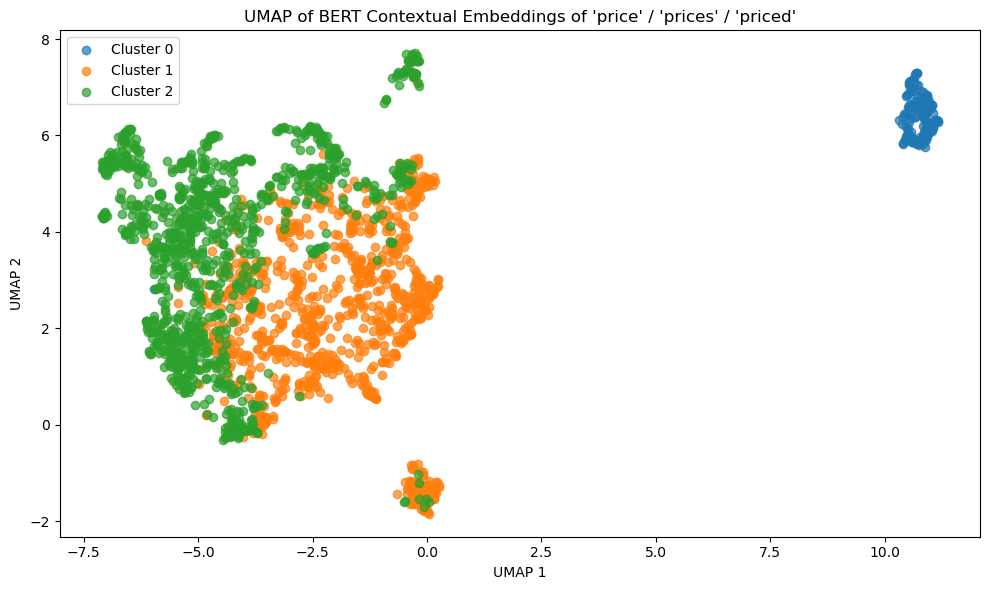


Representative examples by cluster:

===== CLUSTER 0 =====
File: wealth.txt | Sentence ID: 2039 | Form: prices
Context: The respective prices of corn, rice, and sugar, are there
      probably in the natural proportion, or in that which naturally takes place
      in the different crops of the greater part of cultivated land, and which
      recompenses the landlord and farmer, as nearly as can be computed,
      according to what is usually the original expense of improvement, and the
      annual expense of cultivation.

File: A06785.txt | Sentence ID: 563 | Form: prices
Context: But the said Author doth set down the prices as they were in the time of wars, when Merchants charges, P. 45. adventure and all things were increased; and herein he maketh his comparison with Turkey, and according to that computation he affirmeth, that the trade in Spice and Indigo only, saveth the kingdom yearly 74966 l. 13 s. 4 d: and that less than one quarter of this sum shall buy in the Indies the prop

In [13]:
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.cluster import KMeans

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
embed_df["cluster"] = kmeans.fit_predict(X)

print("\nCluster counts:")
print(embed_df["cluster"].value_counts().sort_index())


umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_2d = umap_model.fit_transform(X)

embed_df["umap1"] = X_2d[:, 0]
embed_df["umap2"] = X_2d[:, 1]

plt.figure(figsize=(10, 6))

for c in sorted(embed_df["cluster"].unique()):
    subset = embed_df[embed_df["cluster"] == c]
    plt.scatter(subset["umap1"], subset["umap2"], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of BERT Contextual Embeddings of 'price' / 'prices' / 'priced'")
plt.legend()
plt.tight_layout()
plt.savefig("price_bert_clusters_umap_k3.png", dpi=300, bbox_inches="tight")
plt.show()

distances = pairwise_distances(X, kmeans.cluster_centers_)

for c in range(n_clusters):
    embed_df[f"dist_to_cluster_{c}"] = distances[:, c]

print("\nRepresentative examples by cluster:\n")

for c in range(n_clusters):
    print(f"===== CLUSTER {c} =====")
    reps = (
        embed_df[embed_df["cluster"] == c]
        .sort_values(f"dist_to_cluster_{c}")
        .head(5)
    )
    for _, row in reps.iterrows():
        print(f"File: {row['doc_id']} | Sentence ID: {row['sentence_id']} | Form: {row['matched_form']}")
        print(f"Context: {row['context']}")
        print()

rep_rows = []

for c in range(n_clusters):
    reps = (
        embed_df[embed_df["cluster"] == c]
        .sort_values(f"dist_to_cluster_{c}")
        .head(5)
    ).copy()

    reps["representative_cluster"] = c
    rep_rows.append(reps)

rep_examples_df = pd.concat(rep_rows, ignore_index=True)
rep_examples_df.to_csv("price_representative_examples_k3.csv", index=False)
embed_df.to_csv("price_bert_contexts_clustered_umap_k3.csv", index=False)


In [14]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer

CLUSTERED_FILE = Path("price_bert_contexts_clustered_umap_k3.csv")

TOP_N_TERMS = 12
MAX_FEATURES = 3000
MIN_DF = 2
N_SAMPLE_FILES = 5
N_SAMPLE_CONTEXTS = 5

custom_stopwords = {
    "price", "prices", "priced"  
}

embed_df = pd.read_csv(CLUSTERED_FILE)

print("Loaded clustered occurrence data.")
print(embed_df.head())
print("\nColumns:", list(embed_df.columns))
print("Number of rows:", len(embed_df))

vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z]{4,}\b"
)

tfidf_matrix = vectorizer.fit_transform(embed_df["context"].fillna("").astype(str))
feature_names = np.array(vectorizer.get_feature_names_out())

keep_mask = np.array([term not in custom_stopwords for term in feature_names])

tfidf_matrix = tfidf_matrix[:, keep_mask]
feature_names = feature_names[keep_mask]


def get_top_distinctive_terms(tfidf_matrix, labels, target_cluster, feature_names, top_n=10):
    in_cluster = labels == target_cluster
    out_cluster = labels != target_cluster

    if in_cluster.sum() == 0 or out_cluster.sum() == 0:
        return []

    mean_in = tfidf_matrix[in_cluster].mean(axis=0).A1
    mean_out = tfidf_matrix[out_cluster].mean(axis=0).A1
    diff = mean_in - mean_out

    top_indices = diff.argsort()[-top_n:][::-1]
    top_terms = [(feature_names[i], diff[i]) for i in top_indices if diff[i] > 0]

    return top_terms


labels = embed_df["cluster"].to_numpy()
K = int(embed_df["cluster"].nunique())

print(f"\n=== Cluster Characterization for 'price' (k={K}) ===\n")

for cluster_id in sorted(embed_df["cluster"].unique()):
    cluster_df = embed_df[embed_df["cluster"] == cluster_id].copy()

    print("=" * 70)
    print(f"CLUSTER {cluster_id} — {len(cluster_df)} occurrences")
    print("=" * 70)

    # Top distinctive terms
    top_terms = get_top_distinctive_terms(
        tfidf_matrix=tfidf_matrix,
        labels=labels,
        target_cluster=cluster_id,
        feature_names=feature_names,
        top_n=TOP_N_TERMS
    )

    if top_terms:
        formatted_terms = ", ".join([term for term, score in top_terms])
        print(f"Top distinctive terms: {formatted_terms}")
    else:
        print("Top distinctive terms: (none found)")

    # Most common matched form in this cluster
    form_counts = cluster_df["matched_form"].value_counts()
    print(f"Matched forms: {form_counts.to_dict()}")

    # Sample filenames
    sample_files = cluster_df["doc_id"].dropna().unique().tolist()[:N_SAMPLE_FILES]
    print(f"Sample files: {sample_files}")

    # Sample contexts
    print("Sample contexts:")
    sample_contexts = cluster_df[["doc_id", "sentence_id", "matched_form", "context"]].head(N_SAMPLE_CONTEXTS)

    for _, row in sample_contexts.iterrows():
        print(f"  - File: {row['doc_id']} | Sentence ID: {row['sentence_id']} | Form: {row['matched_form']}")
        print(f"    {row['context']}")
        print()

term_rows = []

for cluster_id in sorted(embed_df["cluster"].unique()):
    top_terms = get_top_distinctive_terms(
        tfidf_matrix=tfidf_matrix,
        labels=labels,
        target_cluster=cluster_id,
        feature_names=feature_names,
        top_n=TOP_N_TERMS
    )

    for rank, (term, score) in enumerate(top_terms, start=1):
        term_rows.append({
            "cluster": cluster_id,
            "rank": rank,
            "term": term,
            "score": score
        })

terms_df = pd.DataFrame(term_rows)
terms_df.to_csv("price_cluster_distinctive_terms_k3.csv", index=False)

print("Saved: price_cluster_distinctive_terms_k3.csv")

Loaded clustered occurrence data.
       doc_id  sentence_id matched_form  \
0  A06785.txt           54       prices   
1  A06785.txt           55        price   
2  A06785.txt           55        price   
3  A06785.txt           56        price   
4  A06785.txt           58        price   

                                             context  start_char  end_char  \
0  Statesmen have observed for a general rule, th...         100       106   
1  Again, when the price of commodities is raised...          16        21   
2  Again, when the price of commodities is raised...          66        71   
3  Likewise when moneys are not imported, when th...         109       114   
4  The general Trade, all the world over, is made...         171       176   

   cluster      umap1     umap2  dist_to_cluster_0  dist_to_cluster_1  \
0        0  10.695929  5.830520           6.511513           9.611114   
1        2  -5.811566  3.228218           7.929396           6.018259   
2        2  -5.7778

In [ ]:
# blue top right isolated cluster
print(embed_df[(embed_df["cluster"] == 0) & (embed_df["umap1"] > 8)])
# save csv of this cluster
embed_df[(embed_df["cluster"] == 0) & (embed_df["umap1"] > 8)].to_csv("price_cluster_0_isolated.csv", index=False)

# 
print(embed_df[(embed_df["umap2"] < -0.8)])
# save csv of this cluster
embed_df[(embed_df["umap2"] < -0.8)].to_csv("price_cluster_1_isolated.csv", index=False)

# 
print(embed_df[(embed_df["cluster"] == 2) & (embed_df["umap2"] > 6)])
# save csv of this cluster
embed_df[(embed_df["cluster"] == 2) & (embed_df["umap2"] > 6)].to_csv("price_cluster_2_isolated.csv", index=False)  

          doc_id  sentence_id matched_form  \
23    A06785.txt          113       prices   
27    A06785.txt          121       prices   
45    A06785.txt          195       prices   
59    A06785.txt          233       prices   
70    A06785.txt          345       prices   
...          ...          ...          ...   
1976  wealth.txt         6226       prices   
1985  wealth.txt         6271       prices   
1994  wealth.txt         6275       prices   
1997  wealth.txt         6282       prices   
1998  wealth.txt         6282       prices   

                                                context  start_char  end_char  \
23    First, by the Assays of moneys made in former ...         126       132   
27    The Rickx Doller being enhanced to 33. shillin...         127       133   
45    And if the said Gentleman had bestowed the las...         104       110   
59    If the moneys were not enhanced beyond the Sea...         104       110   
70    P. 49. 52. and give bridle to the pr

Also see k = 2


Cluster counts:
cluster
0    1064
1    1159
Name: count, dtype: int64


c:\Users\terra\miniforge3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


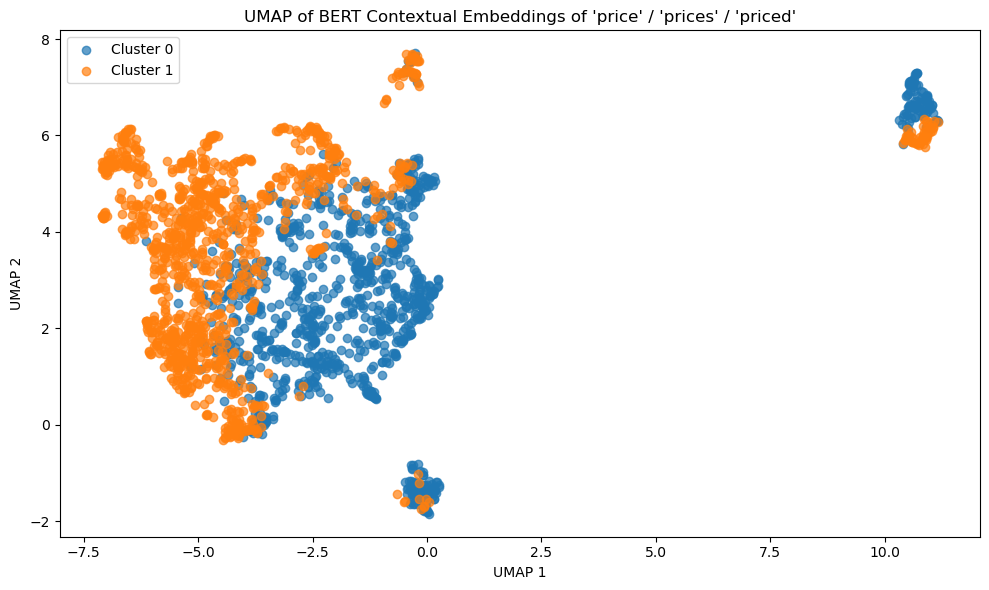


Representative examples by cluster:

===== CLUSTER 0 =====
File: wealth.txt | Sentence ID: 7550 | Form: price
Context: To depress the price of this commodity below what
      may be called its natural and proper price, was the avowed purpose of
      those regulations; and there seems to be no doubt of their having produced
      the effect that was expected from them.

File: wealth.txt | Sentence ID: 2206 | Form: price
Context: Rent accordingly,
      seems at the greater part of mines to have but a small share in the price
      of the coarse, and a still smaller in that of the precious metals. labor
      and profit make up the greater part of both.

File: wealth.txt | Sentence ID: 7289 | Form: price
Context: But if
      the profits of those who deal in such goods are above their proper level,
      those goods will be sold dearer than they ought to be, or somewhat above
      their natural price, and all those engaged in the nearer employments will
      be more or less oppressed

In [15]:
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.cluster import KMeans

n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
embed_df["cluster"] = kmeans.fit_predict(X)

print("\nCluster counts:")
print(embed_df["cluster"].value_counts().sort_index())


umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_2d = umap_model.fit_transform(X)

embed_df["umap1"] = X_2d[:, 0]
embed_df["umap2"] = X_2d[:, 1]

plt.figure(figsize=(10, 6))

for c in sorted(embed_df["cluster"].unique()):
    subset = embed_df[embed_df["cluster"] == c]
    plt.scatter(subset["umap1"], subset["umap2"], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of BERT Contextual Embeddings of 'price' / 'prices' / 'priced'")
plt.legend()
plt.tight_layout()
plt.savefig("price_bert_clusters_umap_k3.png", dpi=300, bbox_inches="tight")
plt.show()

distances = pairwise_distances(X, kmeans.cluster_centers_)

for c in range(n_clusters):
    embed_df[f"dist_to_cluster_{c}"] = distances[:, c]

print("\nRepresentative examples by cluster:\n")

for c in range(n_clusters):
    print(f"===== CLUSTER {c} =====")
    reps = (
        embed_df[embed_df["cluster"] == c]
        .sort_values(f"dist_to_cluster_{c}")
        .head(5)
    )
    for _, row in reps.iterrows():
        print(f"File: {row['doc_id']} | Sentence ID: {row['sentence_id']} | Form: {row['matched_form']}")
        print(f"Context: {row['context']}")
        print()

rep_rows = []

for c in range(n_clusters):
    reps = (
        embed_df[embed_df["cluster"] == c]
        .sort_values(f"dist_to_cluster_{c}")
        .head(5)
    ).copy()

    reps["representative_cluster"] = c
    rep_rows.append(reps)

rep_examples_df = pd.concat(rep_rows, ignore_index=True)
rep_examples_df.to_csv("price_representative_examples_k2.csv", index=False)
embed_df.to_csv("price_bert_contexts_clustered_umap_k2.csv", index=False)


In [16]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer

CLUSTERED_FILE = Path("price_bert_contexts_clustered_umap_k2.csv")

TOP_N_TERMS = 12
MAX_FEATURES = 3000
MIN_DF = 2
N_SAMPLE_FILES = 5
N_SAMPLE_CONTEXTS = 5

custom_stopwords = {
    "price", "prices", "priced"  
}

embed_df = pd.read_csv(CLUSTERED_FILE)

print("Loaded clustered occurrence data.")
print(embed_df.head())
print("\nColumns:", list(embed_df.columns))
print("Number of rows:", len(embed_df))

vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z]{4,}\b"
)

tfidf_matrix = vectorizer.fit_transform(embed_df["context"].fillna("").astype(str))
feature_names = np.array(vectorizer.get_feature_names_out())

keep_mask = np.array([term not in custom_stopwords for term in feature_names])

tfidf_matrix = tfidf_matrix[:, keep_mask]
feature_names = feature_names[keep_mask]


def get_top_distinctive_terms(tfidf_matrix, labels, target_cluster, feature_names, top_n=10):
    in_cluster = labels == target_cluster
    out_cluster = labels != target_cluster

    if in_cluster.sum() == 0 or out_cluster.sum() == 0:
        return []

    mean_in = tfidf_matrix[in_cluster].mean(axis=0).A1
    mean_out = tfidf_matrix[out_cluster].mean(axis=0).A1
    diff = mean_in - mean_out

    top_indices = diff.argsort()[-top_n:][::-1]
    top_terms = [(feature_names[i], diff[i]) for i in top_indices if diff[i] > 0]

    return top_terms


labels = embed_df["cluster"].to_numpy()
K = int(embed_df["cluster"].nunique())

print(f"\n=== Cluster Characterization for 'price' (k={K}) ===\n")

for cluster_id in sorted(embed_df["cluster"].unique()):
    cluster_df = embed_df[embed_df["cluster"] == cluster_id].copy()

    print("=" * 70)
    print(f"CLUSTER {cluster_id} — {len(cluster_df)} occurrences")
    print("=" * 70)

    # Top distinctive terms
    top_terms = get_top_distinctive_terms(
        tfidf_matrix=tfidf_matrix,
        labels=labels,
        target_cluster=cluster_id,
        feature_names=feature_names,
        top_n=TOP_N_TERMS
    )

    if top_terms:
        formatted_terms = ", ".join([term for term, score in top_terms])
        print(f"Top distinctive terms: {formatted_terms}")
    else:
        print("Top distinctive terms: (none found)")

    # Most common matched form in this cluster
    form_counts = cluster_df["matched_form"].value_counts()
    print(f"Matched forms: {form_counts.to_dict()}")

    # Sample filenames
    sample_files = cluster_df["doc_id"].dropna().unique().tolist()[:N_SAMPLE_FILES]
    print(f"Sample files: {sample_files}")

    # Sample contexts
    print("Sample contexts:")
    sample_contexts = cluster_df[["doc_id", "sentence_id", "matched_form", "context"]].head(N_SAMPLE_CONTEXTS)

    for _, row in sample_contexts.iterrows():
        print(f"  - File: {row['doc_id']} | Sentence ID: {row['sentence_id']} | Form: {row['matched_form']}")
        print(f"    {row['context']}")
        print()

term_rows = []

for cluster_id in sorted(embed_df["cluster"].unique()):
    top_terms = get_top_distinctive_terms(
        tfidf_matrix=tfidf_matrix,
        labels=labels,
        target_cluster=cluster_id,
        feature_names=feature_names,
        top_n=TOP_N_TERMS
    )

    for rank, (term, score) in enumerate(top_terms, start=1):
        term_rows.append({
            "cluster": cluster_id,
            "rank": rank,
            "term": term,
            "score": score
        })

terms_df = pd.DataFrame(term_rows)
terms_df.to_csv("price_cluster_distinctive_terms_k2.csv", index=False)

print("Saved: price_cluster_distinctive_terms_k2.csv")

Loaded clustered occurrence data.
       doc_id  sentence_id matched_form  \
0  A06785.txt           54       prices   
1  A06785.txt           55        price   
2  A06785.txt           55        price   
3  A06785.txt           56        price   
4  A06785.txt           58        price   

                                             context  start_char  end_char  \
0  Statesmen have observed for a general rule, th...         100       106   
1  Again, when the price of commodities is raised...          16        21   
2  Again, when the price of commodities is raised...          66        71   
3  Likewise when moneys are not imported, when th...         109       114   
4  The general Trade, all the world over, is made...         171       176   

   cluster      umap1     umap2  dist_to_cluster_0  dist_to_cluster_1  \
0        1  10.695929  5.830520           9.295032           8.152607   
1        1  -5.811566  3.228218           6.031672           4.297728   
2        1  -5.7778

In [68]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency


def extract_org_list(text):
    doc = nlp(str(text))
    return [ent.text for ent in doc.ents if ent.label_ == "ORG"]

org_df = embed_df.copy()
org_df["org_list"] = org_df["context"].apply(extract_org_list)
org_df["has_org"] = org_df["org_list"].apply(lambda x: int(len(x) > 0))
org_df["org_count"] = org_df["org_list"].apply(len)

# contingency table: cluster x has_org
ct = pd.crosstab(org_df["cluster"], org_df["has_org"])
print(ct)

chi2, p, dof, expected = chi2_contingency(ct)
print(f"chi2 = {chi2:.4f}")
print(f"p = {p:.4f}")
print(f"dof = {dof}")

has_org    0    1
cluster          
0        675  389
1        903  256
chi2 = 55.7105
p = 0.0000
dof = 1


In [73]:
from collections import Counter

# explode one row per GPE mention
gpe_exploded = org_df.explode("org_list").dropna(subset=["org_list"]).copy()

# top GPEs overall
top_gpes = gpe_exploded["org_list"].value_counts().head(15)
print(top_gpes)

# frequency of each GPE by cluster
gpe_cluster_table = pd.crosstab(gpe_exploded["org_list"], gpe_exploded["cluster"])
print(gpe_cluster_table.loc[top_gpes.index])
#save csv
gpe_cluster_table.loc[top_gpes.index].to_csv("price_org_cluster_distribution.csv")

org_list
Exchange        206
Trade            99
Commodities      64
Countries        29
Bills            26
Indigo           26
Pepper           25
Mint             24
Nations          21
Commonwealth     20
Ships            20
Merchants        19
Brokeridge       19
Par              18
Clothes          18
Name: count, dtype: int64
cluster        0    1
org_list             
Exchange      97  109
Trade         58   41
Commodities   25   39
Countries     11   18
Bills         18    8
Indigo        23    3
Pepper        23    2
Mint          12   12
Nations       11   10
Commonwealth   8   12
Ships         17    3
Merchants     13    6
Brokeridge    19    0
Par           13    5
Clothes       12    6


In [77]:
gpe_cluster_table["total"] = gpe_cluster_table[0] + gpe_cluster_table[1]
gpe_cluster_table["prop_0"] = gpe_cluster_table[0] / gpe_cluster_table[0].sum()
gpe_cluster_table["prop_1"] = gpe_cluster_table[1] / gpe_cluster_table[1].sum()
gpe_cluster_table["diff"] = gpe_cluster_table["prop_0"] - gpe_cluster_table["prop_1"]

gpe_cluster_table.sort_values("diff", ascending=False).head(15)
# save csv of this table
gpe_cluster_table.sort_values("diff", ascending=False).to_csv("price_org_cluster_proportions.csv")

In [71]:
cluster_org_summary = org_df.groupby("cluster")["org_count"].agg(["mean", "sum", "count"])
print(cluster_org_summary)

             mean   sum  count
cluster                       
0        1.068609  1137   1064
1        0.581536   674   1159


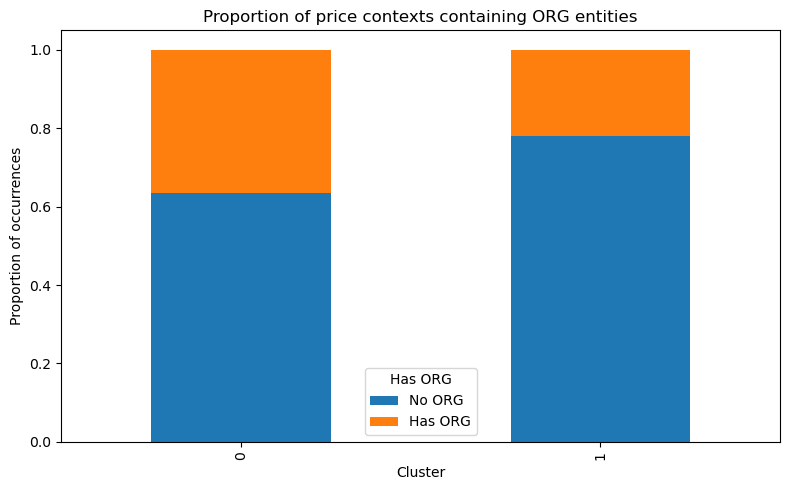

In [72]:
import matplotlib.pyplot as plt

ct_prop = ct.div(ct.sum(axis=1), axis=0)

ct_prop.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.xlabel("Cluster")
plt.ylabel("Proportion of occurrences")
plt.title("Proportion of price contexts containing ORG entities")
plt.legend(title="Has ORG", labels=["No ORG", "Has ORG"])
plt.tight_layout()
plt.show()

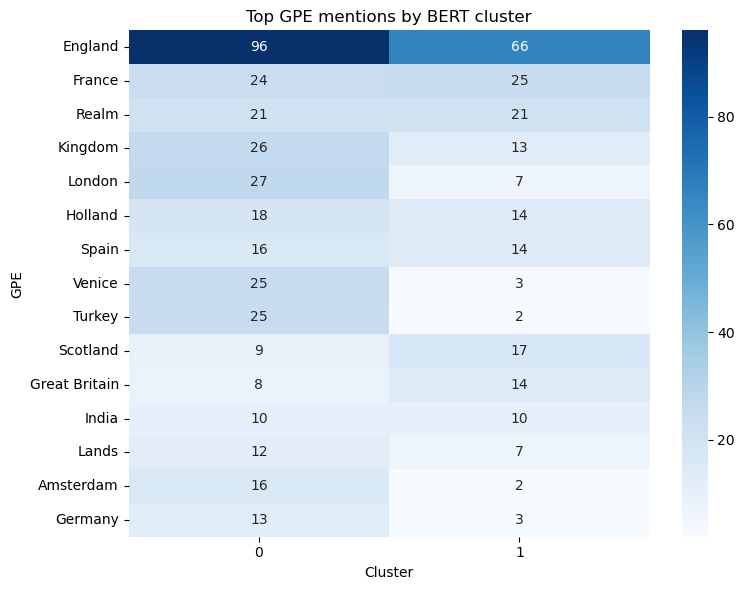

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

top_table = gpe_cluster_table.loc[top_gpes.index]

plt.figure(figsize=(8, 6))
sns.heatmap(top_table, annot=True, fmt="d", cmap="Blues")
plt.title("Top GPE mentions by BERT cluster")
plt.xlabel("Cluster")
plt.ylabel("GPE")
plt.tight_layout()
plt.show()

In [49]:
import pandas as pd
import spacy
from scipy.stats import chi2_contingency

nlp = spacy.load("en_core_web_sm")

df = labeled_df.copy()

def extract_entities(text):
    doc = nlp(str(text))
    return [(ent.text, ent.label_) for ent in doc.ents]

df["entities"] = df["context"].apply(extract_entities)

# explode to one row per entity
ent_df = df.explode("entities").dropna(subset=["entities"]).copy()
ent_df[["entity", "ent_label"]] = pd.DataFrame(ent_df["entities"].tolist(), index=ent_df.index)

# count NER label by semantic label
label_table = pd.crosstab(ent_df["ent_label"], ent_df["label"])
print(label_table)

label        market_exchange  valuation
ent_label                              
CARDINAL                  45         17
DATE                      33         11
FAC                        1          1
GPE                       24          9
LANGUAGE                   2          2
LAW                        2          0
LOC                        6          1
MONEY                      7          2
NORP                      15          3
ORDINAL                    9          5
ORG                       66         29
PERSON                    29          6
PRODUCT                    5          4
QUANTITY                   5          1
TIME                       1          0
WORK_OF_ART                0          3


In [62]:
results = []

for ner_label in ent_df["ent_label"].unique():
    temp = df.copy()

    temp["has_label"] = temp["entities"].apply(
        lambda ents: int(any(lbl == ner_label for _, lbl in ents))
    )

    ct = pd.crosstab(temp["label"], temp["has_label"])

    if ct.shape == (len(temp["label"].unique()), 2):
        chi2, p, dof, expected = chi2_contingency(ct)
        results.append({
            "ner_label": ner_label,
            "chi2": chi2,
            "p_value": p,
            "table": ct.to_dict()
        })

results_df = pd.DataFrame(results).sort_values("p_value")
print(results_df[["ner_label", "chi2", "p_value"]])
# save csv of results
results_df[["ner_label", "chi2", "p_value"]].to_csv("ner_label_chi2_results.csv", index=False)


      ner_label      chi2   p_value
5      CARDINAL  3.135441  0.076608
1          DATE  2.026296  0.154597
2           ORG  1.300889  0.254051
4   WORK_OF_ART  1.246090  0.264301
8        PERSON  0.465051  0.495273
9          NORP  0.167593  0.682260
10          LAW  0.133597  0.714732
6         MONEY  0.123141  0.725652
14     QUANTITY  0.123141  0.725652
11          LOC  0.123141  0.725652
0           GPE  0.015123  0.902128
3       PRODUCT  0.000000  1.000000
7       ORDINAL  0.000000  1.000000
12     LANGUAGE  0.000000  1.000000
13          FAC  0.000000  1.000000
15         TIME  0.000000  1.000000


In [51]:
# specific entity counts by semantic label
entity_table = pd.crosstab(ent_df["entity"], ent_df["label"])

# keep only reasonably frequent entities
entity_table = entity_table[entity_table.sum(axis=1) >= 3]

print(entity_table.sort_values(entity_table.columns.tolist(), ascending=False).head(20))

label        market_exchange  valuation
entity                                 
Trade                      7          4
one                        5          2
two                        5          1
Cloth                      4          1
first                      4          1
Dutch                      4          0
Pepper                     4          0
English                    3          3
Europe                     3          0
Law                        3          0
Nation                     3          0
Strangers                  3          0
d.                         3          0
England                    2          3
Commodities                2          2
Danes                      2          2
Easterlings                2          2
Ships                      2          2
three                      2          2
22                         2          1


In [53]:
distinctive_rows = []

for meaning in entity_table.columns:
    in_class = entity_table[meaning]
    out_class = entity_table.drop(columns=[meaning]).sum(axis=1)
    
    score = in_class - out_class / max(1, (len(entity_table.columns) - 1))
    
    top_entities = score.sort_values(ascending=False).head(15)
    
    for entity, val in top_entities.items():
        distinctive_rows.append({
            "meaning": meaning,
            "entity": entity,
            "distinctiveness_score": val
        })

distinctive_df = pd.DataFrame(distinctive_rows)
print(distinctive_df.head(20))

            meaning         entity  distinctiveness_score
0   market_exchange          Dutch                    4.0
1   market_exchange         Pepper                    4.0
2   market_exchange            two                    4.0
3   market_exchange          Cloth                    3.0
4   market_exchange      Strangers                    3.0
5   market_exchange          Trade                    3.0
6   market_exchange          first                    3.0
7   market_exchange             d.                    3.0
8   market_exchange            Law                    3.0
9   market_exchange         Nation                    3.0
10  market_exchange         Europe                    3.0
11  market_exchange            one                    3.0
12  market_exchange             22                    1.0
13  market_exchange          Tower                    1.0
14  market_exchange  Great Britain                    1.0
15        valuation          Money                    3.0
16        valu

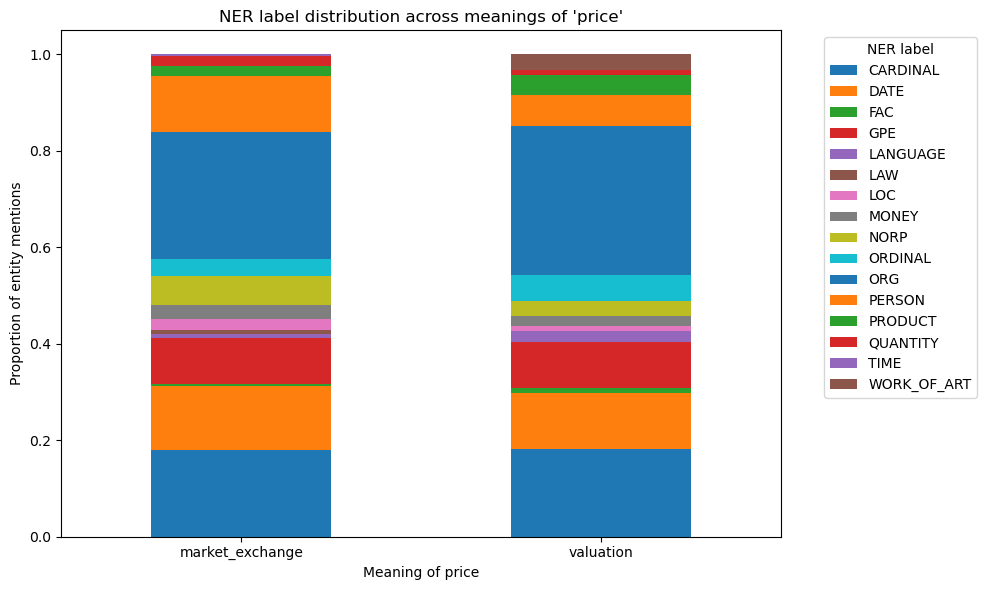

In [61]:
import matplotlib.pyplot as plt

label_prop = pd.crosstab(ent_df["label"], ent_df["ent_label"], normalize="index")

label_prop.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.xlabel("Meaning of price")
plt.xticks(rotation=0, ha="center")
plt.ylabel("Proportion of entity mentions")
plt.title("NER label distribution across meanings of 'price'")
plt.legend(title="NER label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("ner_label_distribution_by_price_meaning.png", dpi=300, bbox_inches="tight")
plt.show()

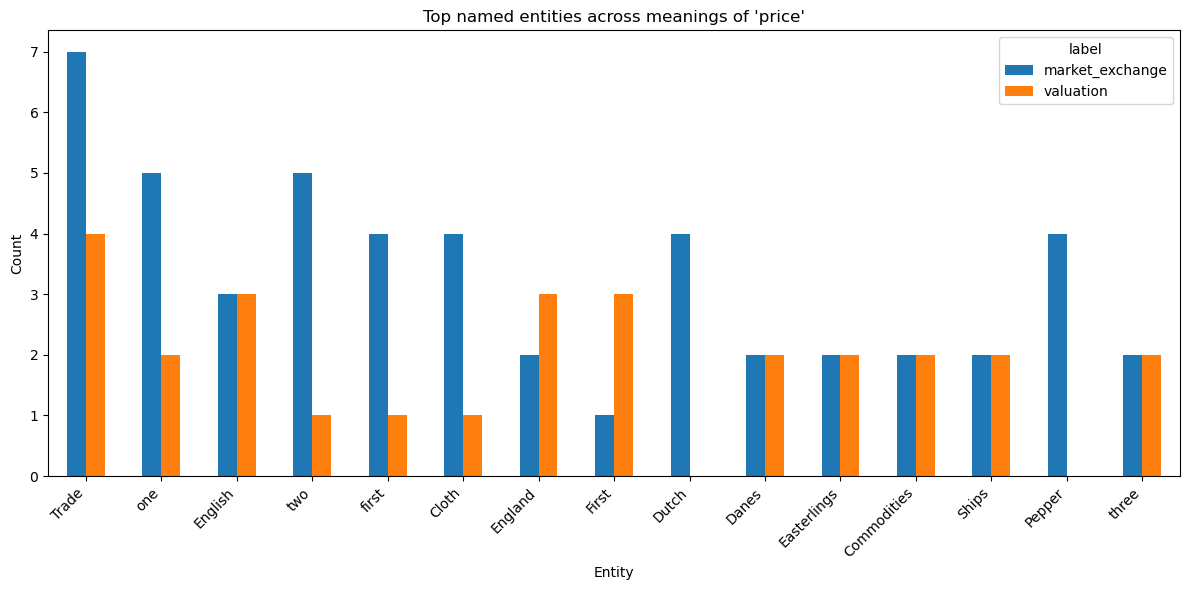

In [55]:
top_entities = entity_table.sum(axis=1).sort_values(ascending=False).head(15).index
plot_table = entity_table.loc[top_entities]

plot_table.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Entity")
plt.ylabel("Count")
plt.title("Top named entities across meanings of 'price'")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("top_named_entities_by_price_meaning.png", dpi=300, bbox_inches="tight")
plt.show()

Step 4 — Supervised Classification (Logistic Regression)

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

CLUSTERED_FILE = Path("price_bert_contexts_clustered_umap_k3.csv")

# for 3 classes, 25 per class gives 75 total, which satisfies the prompt
N_PER_CLUSTER = 25

RANDOM_STATE = 42

custom_stopwords = {"price", "prices", "priced"}


df = pd.read_csv(CLUSTERED_FILE)

print("Loaded clustered data.")
print(df.head())
print("\nCluster counts:")
print(df["cluster"].value_counts().sort_index())



labeling_df = (
    df.groupby("cluster", group_keys=False)
      .apply(lambda x: x.sample(n=min(N_PER_CLUSTER, len(x)), random_state=RANDOM_STATE))
      .reset_index(drop=True)
)

labeling_df = labeling_df[["doc_id", "sentence_id", "matched_form", "context", "cluster"]].copy()
labeling_df["label"] = ""

labeling_df.to_csv("price_labeling_sheet.csv", index=False)

print("\nSaved: price_labeling_sheet.csv")


Loaded clustered data.
       doc_id  sentence_id matched_form  \
0  A06785.txt           54       prices   
1  A06785.txt           55        price   
2  A06785.txt           55        price   
3  A06785.txt           56        price   
4  A06785.txt           58        price   

                                             context  start_char  end_char  \
0  Statesmen have observed for a general rule, th...         100       106   
1  Again, when the price of commodities is raised...          16        21   
2  Again, when the price of commodities is raised...          66        71   
3  Likewise when moneys are not imported, when th...         109       114   
4  The general Trade, all the world over, is made...         171       176   

   cluster      umap1     umap2  dist_to_cluster_0  dist_to_cluster_1  \
0        0  10.695929  5.830520           6.511513           9.611114   
1        2  -5.811566  3.228218           7.929396           6.018259   
2        2  -5.777824  2.97796

C:\Users\terra\AppData\Local\Temp\ipykernel_40932\1855977033.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(N_PER_CLUSTER, len(x)), random_state=RANDOM_STATE))


In [32]:
labeled_df = pd.read_csv("price_labeling_sheet.csv", encoding="cp1252")

labeled_df["label"] = labeled_df["label"].astype("string")
labeled_df = labeled_df[labeled_df["label"].notna() & (labeled_df["label"].str.strip() != "")].copy()

print("\nLabeled examples loaded:", len(labeled_df))
print("\nLabel counts:")
print(labeled_df["label"].value_counts())


Labeled examples loaded: 75

Label counts:
label
market_exchange    47
valuation          28
Name: count, dtype: Int64


In [33]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1,
    max_features=5000,
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"
)

X = vectorizer.fit_transform(labeled_df["context"].astype(str))
feature_names = np.array(vectorizer.get_feature_names_out())

keep_mask = np.array([term not in custom_stopwords for term in feature_names])

X = X[:, keep_mask]
feature_names = feature_names[keep_mask]

le = LabelEncoder()
y = le.fit_transform(labeled_df["label"].astype(str))

print("\nLabel mapping:")
for i, name in enumerate(le.classes_):
    print(f"Label {i} -> {name}")

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    labeled_df.index,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTrain size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

clf = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)

print("\nConfusion matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# sparsity diagnostic
coef = clf.coef_
nonzero = np.count_nonzero(coef)
total = coef.size

print(f"Non-zero coefficients: {nonzero} / {total}")
print(f"Sparsity: {nonzero / total:.4f}")


print("\nTop features by class:\n")

if len(le.classes_) == 2:
    coefs = clf.coef_[0]

    top_pos = coefs.argsort()[-15:][::-1]
    top_neg = coefs.argsort()[:15]

    print(f"Top features for class '{le.classes_[1]}':")
    print(", ".join(feature_names[top_pos]))

    print(f"\nTop features for class '{le.classes_[0]}':")
    print(", ".join(feature_names[top_neg]))

else:
    for i, class_label in enumerate(le.classes_):
        top_idx = clf.coef_[i].argsort()[-15:][::-1]
        print(f"Top features for class '{class_label}':")
        print(", ".join(feature_names[top_idx]))
        print()


# identify which full rows were already manually labeled
key_cols = ["doc_id", "sentence_id", "matched_form", "context"]

labeled_keys = labeled_df[key_cols].copy()
labeled_keys["already_labeled"] = True

full_df = df.merge(labeled_keys, on=key_cols, how="left")
full_df["already_labeled"] = full_df["already_labeled"].fillna(False)

unlabeled_df = full_df[~full_df["already_labeled"]].copy()

print("Remaining unlabeled occurrences:", len(unlabeled_df))

# transform remaining texts with the SAME vectorizer
X_unlabeled = vectorizer.transform(unlabeled_df["context"].astype(str))
X_unlabeled = X_unlabeled[:, keep_mask]

unlabeled_pred = clf.predict(X_unlabeled)
unlabeled_df["predicted_label"] = le.inverse_transform(unlabeled_pred)

# optional probabilities
probs = clf.predict_proba(X_unlabeled)
prob_cols = [f"prob_{label}" for label in le.classes_]
prob_df = pd.DataFrame(probs, columns=prob_cols)

unlabeled_df = pd.concat([unlabeled_df.reset_index(drop=True), prob_df], axis=1)

unlabeled_df.to_csv("price_unlabeled_predictions_tfidf_logreg.csv", index=False)
print("Saved: price_unlabeled_predictions_tfidf_logreg.csv")


Label mapping:
Label 0 -> market_exchange
Label 1 -> valuation

Train size: 52
Test size: 23

Confusion matrix:
[[ 0 14]
 [ 0  9]]

Classification report:
                 precision    recall  f1-score   support

market_exchange       0.00      0.00      0.00        14
      valuation       0.39      1.00      0.56         9

       accuracy                           0.39        23
      macro avg       0.20      0.50      0.28        23
   weighted avg       0.15      0.39      0.22        23

Non-zero coefficients: 0 / 2541
Sparsity: 0.0000

Top features by class:

Top features for class 'valuation':
yield conceive, yield, years preceding, years occasion, years moneys, years deliver, years carry, years amended, years, yearly spent, yearly lad, yearly brought, yearly, year price, year average

Top features for class 'market_exchange':
abated, abated price, ability, ability inferior, abroad, abroad impossible, abroad vnder, absolutely, absolutely necessary, abundance, abundance foreig

c:\Users\terra\miniforge3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\terra\miniforge3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\terra\miniforge3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\terra\AppData\Lo

In [34]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1,
    max_features=5000,
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"
)

X = vectorizer.fit_transform(labeled_df["context"].astype(str))
feature_names = np.array(vectorizer.get_feature_names_out())

keep_mask = np.array([term not in custom_stopwords for term in feature_names])

X = X[:, keep_mask]
feature_names = feature_names[keep_mask]

le = LabelEncoder()
y = le.fit_transform(labeled_df["label"].astype(str))

print("\nLabel mapping:")
for i, name in enumerate(le.classes_):
    print(f"Label {i} -> {name}")

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    labeled_df.index,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTrain size:", X_train.shape[0])
print("Test size:", X_test.shape[0])



Label mapping:
Label 0 -> market_exchange
Label 1 -> valuation

Train size: 52
Test size: 23


In [35]:
print("\nLabel mapping:")
for i, name in enumerate(le.classes_):
    print(f"Label {i} -> {name}")

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    labeled_df.index,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTrain size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

clf = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)

print("\nConfusion matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# sparsity diagnostic
coef = clf.coef_
nonzero = np.count_nonzero(coef)
total = coef.size

print(f"Non-zero coefficients: {nonzero} / {total}")
print(f"Sparsity: {nonzero / total:.4f}")


print("\nTop features by class:\n")

if len(le.classes_) == 2:
    coefs = clf.coef_[0]

    top_pos = coefs.argsort()[-15:][::-1]
    top_neg = coefs.argsort()[:15]

    print(f"Top features for class '{le.classes_[1]}':")
    print(", ".join(feature_names[top_pos]))

    print(f"\nTop features for class '{le.classes_[0]}':")
    print(", ".join(feature_names[top_neg]))

else:
    for i, class_label in enumerate(le.classes_):
        top_idx = clf.coef_[i].argsort()[-15:][::-1]
        print(f"Top features for class '{class_label}':")
        print(", ".join(feature_names[top_idx]))
        print()



Label mapping:
Label 0 -> market_exchange
Label 1 -> valuation

Train size: 52
Test size: 23

Confusion matrix:
[[ 0 14]
 [ 0  9]]

Classification report:
                 precision    recall  f1-score   support

market_exchange       0.00      0.00      0.00        14
      valuation       0.39      1.00      0.56         9

       accuracy                           0.39        23
      macro avg       0.20      0.50      0.28        23
   weighted avg       0.15      0.39      0.22        23

Non-zero coefficients: 0 / 2541
Sparsity: 0.0000

Top features by class:

Top features for class 'valuation':
yield conceive, yield, years preceding, years occasion, years moneys, years deliver, years carry, years amended, years, yearly spent, yearly lad, yearly brought, yearly, year price, year average

Top features for class 'market_exchange':
abated, abated price, ability, ability inferior, abroad, abroad impossible, abroad vnder, absolutely, absolutely necessary, abundance, abundance foreig

c:\Users\terra\miniforge3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\terra\miniforge3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\terra\miniforge3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [36]:
# identify which full rows were already manually labeled
key_cols = ["doc_id", "sentence_id", "matched_form", "context"]

labeled_keys = labeled_df[key_cols].copy()
labeled_keys["already_labeled"] = True

full_df = df.merge(labeled_keys, on=key_cols, how="left")
full_df["already_labeled"] = full_df["already_labeled"].fillna(False)

unlabeled_df = full_df[~full_df["already_labeled"]].copy()

print("Remaining unlabeled occurrences:", len(unlabeled_df))

# transform remaining texts with the SAME vectorizer
X_unlabeled = vectorizer.transform(unlabeled_df["context"].astype(str))
X_unlabeled = X_unlabeled[:, keep_mask]

unlabeled_pred = clf.predict(X_unlabeled)
unlabeled_df["predicted_label"] = le.inverse_transform(unlabeled_pred)

# optional probabilities
probs = clf.predict_proba(X_unlabeled)
prob_cols = [f"prob_{label}" for label in le.classes_]
prob_df = pd.DataFrame(probs, columns=prob_cols)

unlabeled_df = pd.concat([unlabeled_df.reset_index(drop=True), prob_df], axis=1)

unlabeled_df.to_csv("price_unlabeled_predictions_tfidf_logreg.csv", index=False)
print("Saved: price_unlabeled_predictions_tfidf_logreg.csv")

Remaining unlabeled occurrences: 2136
Saved: price_unlabeled_predictions_tfidf_logreg.csv


C:\Users\terra\AppData\Local\Temp\ipykernel_40932\3635562698.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_df["already_labeled"] = full_df["already_labeled"].fillna(False)


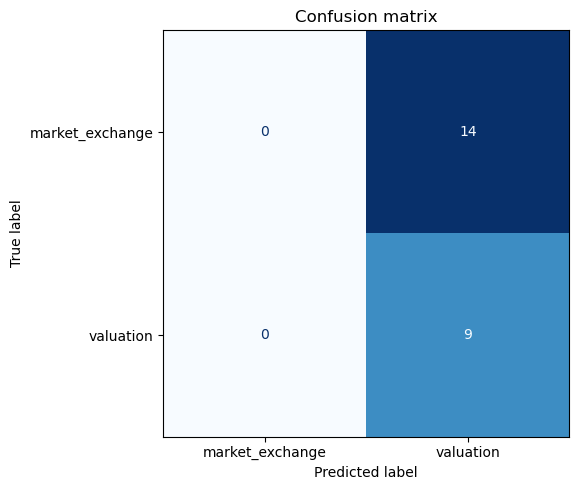

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=range(len(le.classes_)))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title("Confusion matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

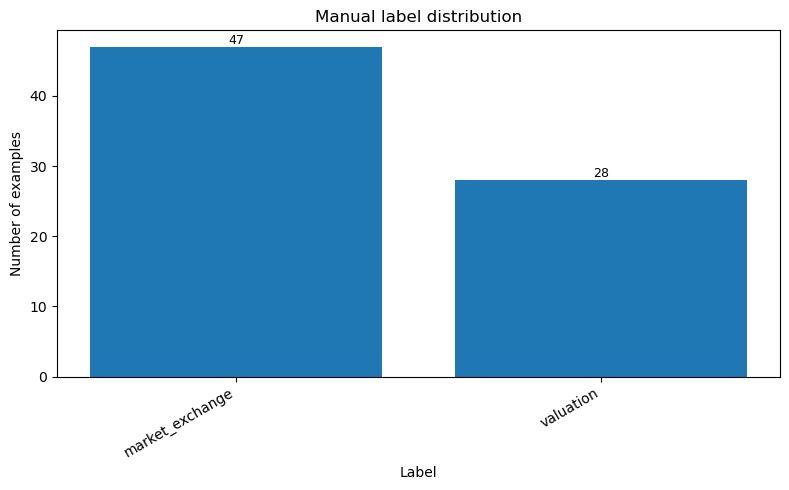

In [20]:
import matplotlib.pyplot as plt

label_counts = labeled_df["label"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(label_counts.index, label_counts.values)

plt.xlabel("Label")
plt.ylabel("Number of examples")
plt.title("Manual label distribution")
plt.xticks(rotation=30, ha="right")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, str(h),
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("manual_label_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

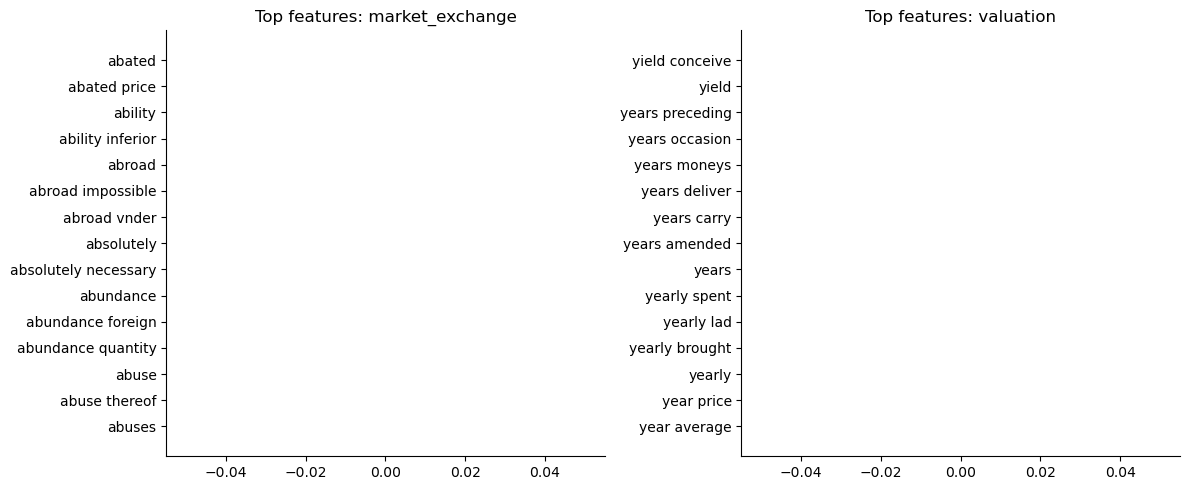

In [21]:
import numpy as np
import matplotlib.pyplot as plt

classes = le.classes_

if len(classes) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

    coefs = clf.coef_[0]

    # class 0 = most negative
    top_neg = np.argsort(coefs)[:15]
    axes[0].barh(feature_names[top_neg], coefs[top_neg])
    axes[0].set_title(f"Top features: {classes[0]}")
    axes[0].invert_yaxis()

    # class 1 = most positive
    top_pos = np.argsort(coefs)[-15:][::-1]
    axes[1].barh(feature_names[top_pos], coefs[top_pos])
    axes[1].set_title(f"Top features: {classes[1]}")
    axes[1].invert_yaxis()

    for ax in axes:
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig("top_features_binary.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 5), sharey=False)

    if len(classes) == 1:
        axes = [axes]

    for i, (cls, ax) in enumerate(zip(classes, axes)):
        coef = clf.coef_[i]
        top_idx = np.argsort(coef)[-15:][::-1]

        ax.barh(feature_names[top_idx], coef[top_idx])
        ax.set_title(f"Class: {cls}")
        ax.invert_yaxis()
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig("top_features_multiclass.png", dpi=300, bbox_inches="tight")
    plt.show()

coef min: -0.24521891319690695
coef max: 0.28485468634717837
nonzero count: 1678
total features: 2541


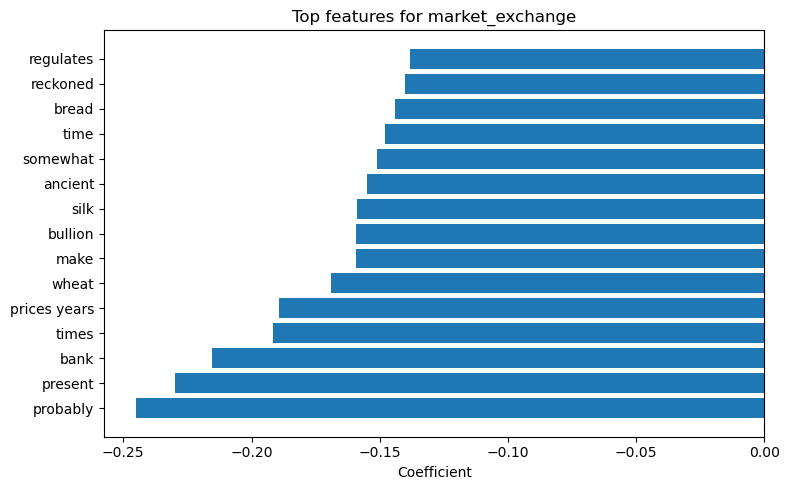

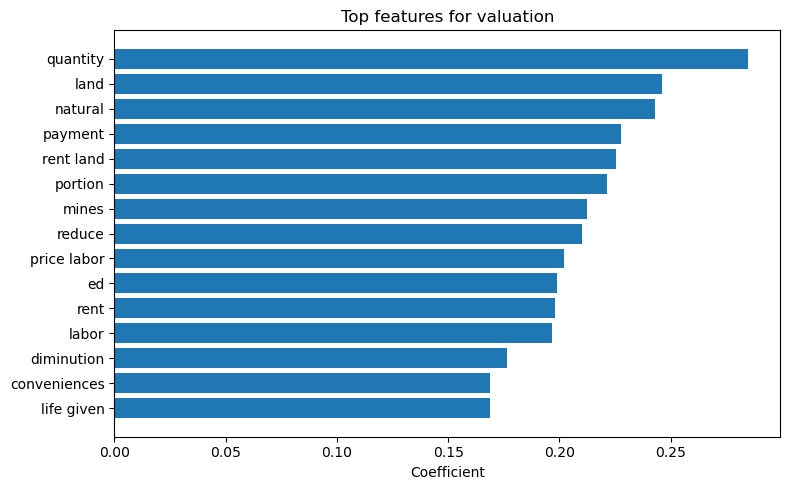

In [30]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# Train L2 model for feature interpretation
clf_l2 = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

clf_l2.fit(X_train, y_train)

coef = clf_l2.coef_[0]
feature_names = np.array(feature_names)

print("coef min:", coef.min())
print("coef max:", coef.max())
print("nonzero count:", np.sum(coef != 0))
print("total features:", len(coef))

# negative coefficients support class 0
# positive coefficients support class 1
top_neg_idx = np.argsort(coef)[:15]
top_pos_idx = np.argsort(coef)[-15:]

plt.figure(figsize=(8, 5))
plt.barh(feature_names[top_neg_idx], coef[top_neg_idx])
plt.title(f"Top features for {le.classes_[0]}")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.barh(feature_names[top_pos_idx], coef[top_pos_idx])
plt.title(f"Top features for {le.classes_[1]}")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

y_pred_l2 = clf_l2.predict(X_test)

print("L2 confusion matrix:")
print(confusion_matrix(y_test, y_pred_l2))

print("\nL2 classification report:")
print(classification_report(y_test, y_pred_l2, target_names=le.classes_))

print("\nPredicted label counts:")
print(pd.Series(le.inverse_transform(y_pred_l2)).value_counts())

L2 confusion matrix:
[[14  0]
 [ 9  0]]

L2 classification report:
                 precision    recall  f1-score   support

market_exchange       0.61      1.00      0.76        14
      valuation       0.00      0.00      0.00         9

       accuracy                           0.61        23
      macro avg       0.30      0.50      0.38        23
   weighted avg       0.37      0.61      0.46        23


Predicted label counts:
market_exchange    23
Name: count, dtype: int64


c:\Users\terra\miniforge3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\terra\miniforge3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\terra\miniforge3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [31]:
print("\nConfusion matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


Confusion matrix:
[[ 0 14]
 [ 0  9]]


labeled_df columns:
Index(['doc_id', 'sentence_id', 'matched_form', 'context', 'cluster', 'label'], dtype='object')

occurrence_df columns:
Index(['doc_id', 'sentence_id', 'matched_form', 'context', 'start_char',
       'end_char', 'predicted_label', 'prediction_confidence',
       'prob_market_exchange', 'prob_valuation'],
      dtype='object')

Label counts in training data:
label
market_exchange    47
valuation          28
Name: count, dtype: Int64

Label mapping:
0 = market_exchange
1 = valuation

Training feature shape:
(75, 2406)

Model trained successfully.

Full dataset feature shape:
(2246, 2406)

Prediction label counts:
predicted_label
market_exchange    2221
valuation            25
Name: count, dtype: int64


,context,predicted_label,prediction_confidence
0,"Statesmen have observed for a general rule, th...",market_exchange,0.621140
1,"Again, when the price of commodities is raised...",market_exchange,0.598861
2,"Again, when the price of commodities is raised...",market_exchange,0.598861
3,"Likewise when moneys are not imported, when th...",market_exchange,0.616485
4,"The general Trade, all the world over, is made...",market_exchange,0.632541
5,"Otherwise, if the money rise in denomination, ...",market_exchange,0.619383
6,So as the words Together with the course of Ex...,market_exchange,0.624064
7,So as the words Together with the course of Ex...,market_exchange,0.624064
8,"To make this more evident, General Rules, cons...",market_exchange,0.558477
9,"And so it is in matters of Exchanges, whereby ...",market_exchange,0.631321


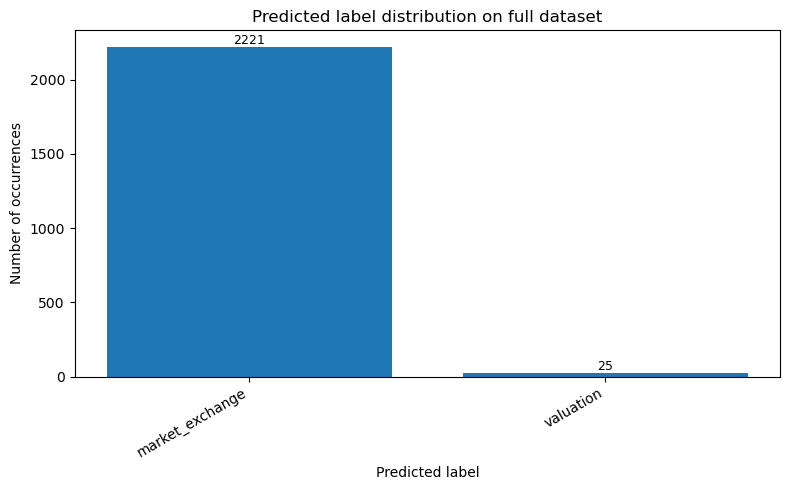


Saved files:
1. predicted_label_distribution.png
2. occurrence_df_with_predictions.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder


TEXT_COL = "context"
LABEL_COL = "label"


labeled_df = labeled_df.copy()

labeled_df[TEXT_COL] = labeled_df[TEXT_COL].astype(str)
labeled_df[LABEL_COL] = labeled_df[LABEL_COL].astype("string")

# Keep only rows with a real label
labeled_df = labeled_df[
    labeled_df[LABEL_COL].notna() &
    (labeled_df[LABEL_COL].str.strip() != "")
].copy()

# Remove extra spaces from labels
labeled_df[LABEL_COL] = labeled_df[LABEL_COL].str.strip()

print("\nLabel counts in training data:")
print(labeled_df[LABEL_COL].value_counts())



if labeled_df[LABEL_COL].nunique() < 2:
    raise ValueError("You need at least two different labels to train a classifier.")



le = LabelEncoder()
y_train = le.fit_transform(labeled_df[LABEL_COL])

print("\nLabel mapping:")
for number, label in enumerate(le.classes_):
    print(number, "=", label)



vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    token_pattern=r"(?u)\b[a-zA-Z]{4,}\b"
)

X_train = vectorizer.fit_transform(labeled_df[TEXT_COL])

print("\nTraining feature shape:")
print(X_train.shape)



clf_l2 = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

clf_l2.fit(X_train, y_train)

print("\nModel trained successfully.")



occurrence_df = occurrence_df.copy()
occurrence_df[TEXT_COL] = occurrence_df[TEXT_COL].astype(str)

X_all = vectorizer.transform(occurrence_df[TEXT_COL])

print("\nFull dataset feature shape:")
print(X_all.shape)

pred_encoded = clf_l2.predict(X_all)
occurrence_df["predicted_label"] = le.inverse_transform(pred_encoded)



proba = clf_l2.predict_proba(X_all)

occurrence_df["prediction_confidence"] = proba.max(axis=1)

# Optional: add probability for each label
label_names = le.inverse_transform(clf_l2.classes_)

for i, label in enumerate(label_names):
    occurrence_df[f"prob_{label}"] = proba[:, i]


print("\nPrediction label counts:")
print(occurrence_df["predicted_label"].value_counts())

display(
    occurrence_df[
        [TEXT_COL, "predicted_label", "prediction_confidence"]
    ].head(10)
)



pred_counts = occurrence_df["predicted_label"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(pred_counts.index, pred_counts.values)

plt.xlabel("Predicted label")
plt.ylabel("Number of occurrences")
plt.title("Predicted label distribution on full dataset")
plt.xticks(rotation=30, ha="right")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        str(int(h)),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("predicted_label_distribution.png", dpi=300, bbox_inches="tight")
plt.show()



occurrence_df.to_csv("occurrence_df_with_predictions.csv", index=False)

print("\nSaved files:")
print("1. predicted_label_distribution.png")
print("2. occurrence_df_with_predictions.csv")

In [41]:
import re
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder


df_all = occurrence_df.copy()


TEXT_COL = "context"


df_labeled = labeled_df.copy()

# Clean labeled data
df_labeled = df_labeled[
    df_labeled["label"].notna() &
    (df_labeled["label"].astype(str).str.strip() != "")
].copy()

df_labeled["label"] = df_labeled["label"].astype(str).str.strip()

print("All occurrence data:", df_all.shape)
print("Labeled data:", df_labeled.shape)
print("Labels:")
print(df_labeled["label"].value_counts())


market_exchange_terms = {
    "shilling", "shillings",
    "paid", "pay", "payment",
    "sell", "selling", "sold",
    "pound", "pounds",
    "pence",
    "reckoned", "reckon",
    "cost", "costs",
    "east"
}

valuation_terms = {
    "labor", "labour",
    "rise", "rises", "raise", "raised",
    "commodity", "commodities",
    "real",
    "corn",
    "money",
    "market", "markets",
    "natural",
    "home",
    "provisions",
    "value", "values", "worth"
}


def tokenize(text):
    return re.findall(r"[a-zA-Z]+", str(text).lower())

def get_hits(text, vocab):
    tokens = tokenize(text)
    return sorted(set(tokens).intersection(vocab))

def overlap_features(text):
    market_hits = get_hits(text, market_exchange_terms)
    valuation_hits = get_hits(text, valuation_terms)

    market_count = len(market_hits)
    valuation_count = len(valuation_hits)

    is_overlap = int(market_count > 0 and valuation_count > 0)

    overlap_score = is_overlap * (market_count + valuation_count)

    return pd.Series({
        "market_exchange_hits": ", ".join(market_hits),
        "valuation_hits": ", ".join(valuation_hits),
        "market_exchange_count": market_count,
        "valuation_count": valuation_count,
        "lexical_overlap_score": overlap_score
    })

overlap_info = df_all[TEXT_COL].apply(overlap_features)
df_overlap = pd.concat([df_all, overlap_info], axis=1)


le = LabelEncoder()
y = le.fit_transform(df_labeled["label"])

print("\nLabel mapping:")
for i, label in enumerate(le.classes_):
    print(i, "->", label)

pipe_l2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.95,
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b"
    )),
    ("clf", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

pipe_l2.fit(df_labeled[TEXT_COL].astype(str), y)


proba = pipe_l2.predict_proba(df_overlap[TEXT_COL].astype(str))

market_idx = list(le.classes_).index("market_exchange")
valuation_idx = list(le.classes_).index("valuation")

df_overlap["p_market_exchange"] = proba[:, market_idx]
df_overlap["p_valuation"] = proba[:, valuation_idx]

df_overlap["model_ambiguity"] = 1 - abs(
    df_overlap["p_market_exchange"] - df_overlap["p_valuation"]
)


df_overlap["close_reading_score"] = (
    df_overlap["lexical_overlap_score"] +
    2 * df_overlap["model_ambiguity"]
)


close_reading_candidates = df_overlap[
    (df_overlap["market_exchange_count"] > 0) &
    (df_overlap["valuation_count"] > 0)
].copy()

close_reading_candidates = close_reading_candidates.sort_values(
    "close_reading_score",
    ascending=False
)

cols = [
    TEXT_COL,
    "market_exchange_hits",
    "valuation_hits",
    "lexical_overlap_score",
    "p_market_exchange",
    "p_valuation",
    "model_ambiguity",
    "close_reading_score"
]


if "document" in close_reading_candidates.columns:
    cols = ["document"] + cols

close_reading_candidates[cols].head(20)

All occurrence data: (2246, 10)
Labeled data: (75, 6)
Labels:
label
market_exchange    47
valuation          28
Name: count, dtype: int64

Label mapping:
0 -> market_exchange
1 -> valuation


,context,market_exchange_hits,valuation_hits,lexical_overlap_score,p_market_exchange,p_valuation,model_ambiguity,close_reading_score
865,Also we ought to esteem and cherish those trad...,"east, pence, pound, shillings, sold","commodities, natural, worth",8,0.568667,0.431333,0.862665,9.725331
1031,The commodity is then sold precisely for what ...,"cost, costs, sell, sold","commodity, market, worth",7,0.504487,0.495513,0.991026,8.982052
179,A Merchant in Spain dealing for the West Indie...,"cost, paid, payment, pounds","commodities, money, value",7,0.518662,0.481338,0.962677,8.925354
158,By Bills of Exchange. 3 There is another buyin...,"paid, pounds, selling","commodities, money, value, worth",7,0.525434,0.474566,0.949132,8.898264
159,By Bills of Exchange. 3 There is another buyin...,"paid, pounds, selling","commodities, money, value, worth",7,0.525434,0.474566,0.949132,8.898264
77,"THere is not any such thing in my writings, ne...","paid, payment, sell, selling, sold","commodities, money",7,0.474326,0.525674,0.948651,8.897302
76,"THere is not any such thing in my writings, ne...","paid, payment, sell, selling, sold","commodities, money",7,0.474326,0.525674,0.948651,8.897302
1439,"Silver sunk in its real value, or would\n ...","shillings, sold","corn, labor, money, real, value",7,0.527684,0.472316,0.944632,8.889263
238,THe Shillings of all the several Provinces res...,"paid, payment, pound, sell, shillings","money, value",7,0.532630,0.467370,0.934741,8.869482
237,THe Shillings of all the several Provinces res...,"paid, payment, pound, sell, shillings","money, value",7,0.532630,0.467370,0.934741,8.869482


In [ ]:
close_reading_candidates[cols].head(20).to_csv(
    "step5_close_reading_candidates_top20.csv",
    index=False,
    encoding="utf-8-sig"
)

close_reading_candidates[cols].to_csv(
    "step5_close_reading_candidates_all.csv",
    index=False,
    encoding="utf-8-sig"
)



Saved:
step5_close_reading_candidates_top20.csv
step5_close_reading_candidates_all.csv
